In [1]:
!pip install -q catboost lightgbm optuna shap

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from catboost import CatBoostClassifier

import matplotlib.pyplot as plt

In [10]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos/PCOS_data_without_infertility.xlsx
/kaggle/input/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos/PCOS_infertility.csv


In [23]:
import pandas as pd

file_path = "/kaggle/input/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos/PCOS_data_without_infertility.xlsx"

xls = pd.ExcelFile(file_path)

print("Sheets:", xls.sheet_names)

for sheet in xls.sheet_names:
    print(f"\n===== {sheet} =====")
    temp = pd.read_excel(file_path, sheet_name=sheet, header=None)
    print(temp.head(10))
    print("\nShape:", temp.shape)

Sheets: ['Instructions', 'Full_new']

===== Instructions =====
                               0  \
0  Instructions to be followed :   
1                            NaN   
2                              1   
3                              2   
4                              3   
5                              4   
6                              5   
7                            NaN   
8                            NaN   
9                            NaN   

                                                   1   2        3  
0                                                NaN NaN      NaN  
1                                                NaN NaN      NaN  
2   Kindly ensure that the datas are converted to... NaN      NaN  
3    Please fill up the entire data set of a patient NaN      NaN  
4  Manipulated datas if any need to be highlighte... NaN      NaN  
5  For every Yes/No questions *** ,  Indicate Yes... NaN      NaN  
6                         Blood Group indications ** NaN  A+ = 1

In [24]:
import pandas as pd

file_path = "/kaggle/input/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos/PCOS_data_without_infertility.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Full_new",
    header=0
)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (541, 45)

Columns:
['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'Unnamed: 44']

First 5 rows:


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [26]:
print("=" * 60)
print("Shape:", df.shape)

print("\n" + "=" * 60)
print("Data Types:")
print(df.dtypes)

print("\n" + "=" * 60)
print("Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n" + "=" * 60)
print("Duplicate Rows:", df.duplicated().sum())

print("\n" + "=" * 60)
print("Target Distribution:")
print(df["PCOS (Y/N)"].value_counts())

print("\n" + "=" * 60)
print("Unique values in target:")
print(df["PCOS (Y/N)"].unique())

Shape: (541, 45)

Data Types:
Sl. No                      int64
Patient File No.            int64
PCOS (Y/N)                  int64
 Age (yrs)                  int64
Weight (Kg)               float64
Height(Cm)                float64
BMI                       float64
Blood Group                 int64
Pulse rate(bpm)             int64
RR (breaths/min)            int64
Hb(g/dl)                  float64
Cycle(R/I)                  int64
Cycle length(days)          int64
Marraige Status (Yrs)     float64
Pregnant(Y/N)               int64
No. of aborptions           int64
  I   beta-HCG(mIU/mL)    float64
II    beta-HCG(mIU/mL)     object
FSH(mIU/mL)               float64
LH(mIU/mL)                float64
FSH/LH                    float64
Hip(inch)                   int64
Waist(inch)                 int64
Waist:Hip Ratio           float64
TSH (mIU/L)               float64
AMH(ng/mL)                 object
PRL(ng/mL)                float64
Vit D3 (ng/mL)            float64
PRG(ng/mL)        

In [27]:
# Investigate object columns

object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    print("=" * 80)
    print(f"Column: {col}")
    print("Unique sample values:")
    print(df[col].dropna().unique()[:20])
    print("\n")

Column: II    beta-HCG(mIU/mL)
Unique sample values:
[1.99 494.08 801.45 100.51 158.51 1214.23 91.55 749.98 218.65 13 610.63
 4490.18 11.24 15 768.03 12 10 20 30.66 1455]


Column: AMH(ng/mL)
Unique sample values:
[2.07 1.53 6.63 1.22 2.26 6.74 3.05 1.54 1 1.61 4.47 1.67 7.94 2.38 0.88
 0.69 3.78 1.92 2.85 2.13]


Column: Unnamed: 44
Unique sample values:
['.' 7]




In [28]:
print(df.select_dtypes(include="object").columns.tolist())

['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)', 'Unnamed: 44']


In [29]:
for col in ['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)', 'Unnamed: 44']:
    print("=" * 80)
    print(f"Column: {col}")
    print(df[col].head(20).tolist())
    print("\nUnique non-null sample:")
    print(df[col].dropna().unique()[:20])
    print()

Column: II    beta-HCG(mIU/mL)
[1.99, 1.99, 494.08, 1.99, 801.45, 1.99, 1.99, 100.51, 1.99, 1.99, 158.51, 1.99, 1214.23, 1.99, 1.99, 1.99, 91.55, 1.99, 1.99, 1.99]

Unique non-null sample:
[1.99 494.08 801.45 100.51 158.51 1214.23 91.55 749.98 218.65 13 610.63
 4490.18 11.24 15 768.03 12 10 20 30.66 1455]

Column: AMH(ng/mL)
[2.07, 1.53, 6.63, 1.22, 2.26, 6.74, 3.05, 1.54, 1, 1.61, 4.47, 1.67, 7.94, 2.38, 0.88, 0.69, 3.78, 1.92, 1, 2.07]

Unique non-null sample:
[2.07 1.53 6.63 1.22 2.26 6.74 3.05 1.54 1 1.61 4.47 1.67 7.94 2.38 0.88
 0.69 3.78 1.92 2.85 2.13]

Column: Unnamed: 44
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Unique non-null sample:
['.' 7]



In [30]:
# Remove junk column
df = df.drop(columns=["Unnamed: 44"])

# Convert object columns to numeric
cols_to_numeric = [
    "II    beta-HCG(mIU/mL)",
    "AMH(ng/mL)"
]

for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape:", df.shape)

print("\nData Types:")
print(df[cols_to_numeric].dtypes)

print("\nMissing Values:")
print(df[cols_to_numeric + ["Marraige Status (Yrs)", "Fast food (Y/N)"]].isnull().sum())

Shape: (541, 44)

Data Types:
II    beta-HCG(mIU/mL)    float64
AMH(ng/mL)                float64
dtype: object

Missing Values:
II    beta-HCG(mIU/mL)    1
AMH(ng/mL)                1
Marraige Status (Yrs)     1
Fast food (Y/N)           1
dtype: int64


In [31]:
missing_rows = df[df.isnull().any(axis=1)]

print("Rows with missing values:", len(missing_rows))

display(
    missing_rows[
        [
            "Patient File No.",
            "PCOS (Y/N)",
            "Marraige Status (Yrs)",
            "Fast food (Y/N)",
            "II    beta-HCG(mIU/mL)",
            "AMH(ng/mL)"
        ]
    ]
)

Rows with missing values: 4


,Patient File No.,PCOS (Y/N),Marraige Status (Yrs),Fast food (Y/N),II beta-HCG(mIU/mL),AMH(ng/mL)
123,124,1,2.0,1.0,NaN,19.80
156,157,0,5.0,NaN,1.99,5.27
305,306,0,9.0,0.0,1.99,NaN
458,459,1,NaN,0.0,1.99,6.60


In [32]:
# Median for continuous features
continuous_cols = [
    "II    beta-HCG(mIU/mL)",
    "AMH(ng/mL)",
    "Marraige Status (Yrs)"
]

for col in continuous_cols:
    df[col] = df[col].fillna(df[col].median())

# Mode for binary feature
df["Fast food (Y/N)"] = df["Fast food (Y/N)"].fillna(
    df["Fast food (Y/N)"].mode()[0]
)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

print("\nDataset Shape:", df.shape)

Missing values after cleaning:
0

Dataset Shape: (541, 44)


In [33]:
print("=" * 80)
print("Total Columns:", len(df.columns))

print("\nColumns:\n")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Total Columns: 44

Columns:

 1. Sl. No
 2. Patient File No.
 3. PCOS (Y/N)
 4.  Age (yrs)
 5. Weight (Kg)
 6. Height(Cm) 
 7. BMI
 8. Blood Group
 9. Pulse rate(bpm) 
10. RR (breaths/min)
11. Hb(g/dl)
12. Cycle(R/I)
13. Cycle length(days)
14. Marraige Status (Yrs)
15. Pregnant(Y/N)
16. No. of aborptions
17.   I   beta-HCG(mIU/mL)
18. II    beta-HCG(mIU/mL)
19. FSH(mIU/mL)
20. LH(mIU/mL)
21. FSH/LH
22. Hip(inch)
23. Waist(inch)
24. Waist:Hip Ratio
25. TSH (mIU/L)
26. AMH(ng/mL)
27. PRL(ng/mL)
28. Vit D3 (ng/mL)
29. PRG(ng/mL)
30. RBS(mg/dl)
31. Weight gain(Y/N)
32. hair growth(Y/N)
33. Skin darkening (Y/N)
34. Hair loss(Y/N)
35. Pimples(Y/N)
36. Fast food (Y/N)
37. Reg.Exercise(Y/N)
38. BP _Systolic (mmHg)
39. BP _Diastolic (mmHg)
40. Follicle No. (L)
41. Follicle No. (R)
42. Avg. F size (L) (mm)
43. Avg. F size (R) (mm)
44. Endometrium (mm)


In [35]:
# Feature summary

TARGET = "PCOS (Y/N)"

DROP_COLUMNS = [
    "Sl. No",
    "Patient File No."
]

FEATURES = [col for col in df.columns if col not in DROP_COLUMNS + [TARGET]]

print(f"Target : {TARGET}")
print(f"Number of Features : {len(FEATURES)}")

print("\nFeatures:\n")

for i, feature in enumerate(FEATURES, 1):
    print(f"{i:2d}. {feature}")

Target : PCOS (Y/N)
Number of Features : 41

Features:

 1.  Age (yrs)
 2. Weight (Kg)
 3. Height(Cm) 
 4. BMI
 5. Blood Group
 6. Pulse rate(bpm) 
 7. RR (breaths/min)
 8. Hb(g/dl)
 9. Cycle(R/I)
10. Cycle length(days)
11. Marraige Status (Yrs)
12. Pregnant(Y/N)
13. No. of aborptions
14.   I   beta-HCG(mIU/mL)
15. II    beta-HCG(mIU/mL)
16. FSH(mIU/mL)
17. LH(mIU/mL)
18. FSH/LH
19. Hip(inch)
20. Waist(inch)
21. Waist:Hip Ratio
22. TSH (mIU/L)
23. AMH(ng/mL)
24. PRL(ng/mL)
25. Vit D3 (ng/mL)
26. PRG(ng/mL)
27. RBS(mg/dl)
28. Weight gain(Y/N)
29. hair growth(Y/N)
30. Skin darkening (Y/N)
31. Hair loss(Y/N)
32. Pimples(Y/N)
33. Fast food (Y/N)
34. Reg.Exercise(Y/N)
35. BP _Systolic (mmHg)
36. BP _Diastolic (mmHg)
37. Follicle No. (L)
38. Follicle No. (R)
39. Avg. F size (L) (mm)
40. Avg. F size (R) (mm)
41. Endometrium (mm)


In [36]:
# Correlation of every numerical feature with the target

TARGET = "PCOS (Y/N)"

corr = (
    df.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)

print(corr)

Follicle No. (R)          0.648327
Follicle No. (L)          0.603346
Skin darkening (Y/N)      0.475733
hair growth(Y/N)          0.464667
Weight gain(Y/N)          0.441047
Cycle(R/I)                0.401644
Fast food (Y/N)           0.376183
Pimples(Y/N)              0.286077
AMH(ng/mL)                0.264141
Weight (Kg)               0.211938
BMI                       0.199534
Hair loss(Y/N)            0.172879
Waist(inch)               0.164598
Hip(inch)                 0.162297
Avg. F size (L) (mm)      0.132992
Endometrium (mm)          0.106648
Avg. F size (R) (mm)      0.097690
Pulse rate(bpm)           0.091821
Hb(g/dl)                  0.087170
Vit D3 (ng/mL)            0.085494
Height(Cm)                0.068254
Reg.Exercise(Y/N)         0.065337
LH(mIU/mL)                0.063879
Sl. No                    0.060998
Patient File No.          0.060998
RBS(mg/dl)                0.048922
BP _Diastolic (mmHg)      0.038032
RR (breaths/min)          0.036928
Blood Group         

In [37]:
import numpy as np

TARGET = "PCOS (Y/N)"

# Remove target and IDs
feature_df = df.drop(columns=[
    TARGET,
    "Sl. No",
    "Patient File No."
])

corr_matrix = feature_df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
    .sort_values(ascending=False)
)

high_corr = high_corr[high_corr > 0.80]

print("Highly Correlated Feature Pairs (>0.80):\n")

print(high_corr)

Highly Correlated Feature Pairs (>0.80):

FSH(mIU/mL)  FSH/LH         0.971946
Weight (Kg)  BMI            0.901675
Hip(inch)    Waist(inch)    0.873411
dtype: float64


In [38]:
# Numerical feature summary

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

summary = df[numerical_cols].describe().T

summary = summary[
    ["min", "25%", "50%", "75%", "max", "mean", "std"]
].round(2)

display(summary)

,min,25%,50%,75%,max,mean,std
Sl. No,1.00,136.00,271.00,406.00,541.00,271.00,156.32
Patient File No.,1.00,136.00,271.00,406.00,541.00,271.00,156.32
PCOS (Y/N),0.00,0.00,0.00,1.00,1.00,0.33,0.47
Age (yrs),20.00,28.00,31.00,35.00,48.00,31.43,5.41
Weight (Kg),31.00,52.00,59.00,65.00,108.00,59.64,11.03
Height(Cm),137.00,152.00,156.00,160.00,180.00,156.48,6.03
BMI,12.42,21.64,24.24,26.63,38.90,24.31,4.06
Blood Group,11.00,13.00,14.00,15.00,18.00,13.80,1.84
Pulse rate(bpm),13.00,72.00,72.00,74.00,82.00,73.25,4.43
RR (breaths/min),16.00,18.00,18.00,20.00,28.00,19.24,1.69


In [39]:
TARGET = "PCOS (Y/N)"

DROP_COLUMNS = [
    "Sl. No",
    "Patient File No.",
    TARGET
]

X = df.drop(columns=DROP_COLUMNS)

y = df[TARGET]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (541, 41)
y Shape: (541,)


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (432, 41)
Testing : (109, 41)


In [41]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    eval_metric="AUC",
    loss_function="Logloss",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.9221842	best: 0.9221842 (0)	total: 56.5ms	remaining: 56.5s
100:	test: 0.9505327	best: 0.9512938 (95)	total: 314ms	remaining: 2.79s
200:	test: 0.9528158	best: 0.9539574 (150)	total: 566ms	remaining: 2.25s
300:	test: 0.9528158	best: 0.9539574 (150)	total: 822ms	remaining: 1.91s
400:	test: 0.9562405	best: 0.9566210 (398)	total: 1.07s	remaining: 1.6s
500:	test: 0.9550989	best: 0.9566210 (398)	total: 1.33s	remaining: 1.32s
600:	test: 0.9547184	best: 0.9566210 (398)	total: 1.58s	remaining: 1.05s
700:	test: 0.9539574	best: 0.9566210 (398)	total: 1.84s	remaining: 783ms
800:	test: 0.9528158	best: 0.9566210 (398)	total: 2.09s	remaining: 519ms
900:	test: 0.9524353	best: 0.9566210 (398)	total: 2.34s	remaining: 258ms
999:	test: 0.9520548	best: 0.9566210 (398)	total: 2.6s	remaining: 0us

bestTest = 0.9566210046
bestIteration = 398

Shrink model to first 399 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9083
Precision: 0.9062
Recall   : 0.8056
F1 Score : 0.8529
ROC AUC  : 0.9566

Confusion Matrix
[[70  3]
 [ 7 29]]


In [43]:
feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.get_feature_importance()
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)

,Feature,Importance
0,Follicle No. (R),19.274662
1,Follicle No. (L),7.870969
2,hair growth(Y/N),7.107814
3,Skin darkening (Y/N),5.349028
4,Weight gain(Y/N),5.003175
5,AMH(ng/mL),3.882013
6,Cycle(R/I),3.609975
7,Cycle length(days),3.377243
8,Pimples(Y/N),3.018861
9,Marraige Status (Yrs),2.425018


In [44]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Train Accuracy :", accuracy_score(y_train, train_pred))
print("Test Accuracy  :", accuracy_score(y_test, test_pred))

Train Accuracy : 1.0
Test Accuracy  : 0.908256880733945


In [45]:
# ==============================
# Feature Engineering
# ==============================

df_fe = df.copy()

# Total follicles
df_fe["Total Follicles"] = (
    df_fe["Follicle No. (L)"] +
    df_fe["Follicle No. (R)"]
)

# Average follicle size
df_fe["Average Follicle Size"] = (
    df_fe["Avg. F size (L) (mm)"] +
    df_fe["Avg. F size (R) (mm)"]
) / 2

# Hormone ratio
df_fe["LH/FSH Ratio"] = (
    df_fe["LH(mIU/mL)"] /
    (df_fe["FSH(mIU/mL)"] + 1e-6)
)

# Waist to Height Ratio
df_fe["Waist Height Ratio"] = (
    df_fe["Waist(inch)"] /
    df_fe["Height(Cm) "]
)

print(df_fe.shape)

(541, 48)


In [49]:
TARGET = "PCOS (Y/N)"

DROP_COLUMNS = [
    "Sl. No",
    "Patient File No.",
    TARGET
]

X = df_fe.drop(columns=DROP_COLUMNS)

y = df_fe[TARGET]

In [50]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [51]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(

    iterations=1500,

    depth=7,

    learning_rate=0.02,

    loss_function="Logloss",

    eval_metric="AUC",

    random_seed=42,

    verbose=False
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_test,y_test),
    use_best_model=True
)

CatBoostClassifier(depth=7, eval_metric='AUC', iterations=1500, learning_rate=0.02, loss_function='Logloss', random_seed=42, verbose=False)

In [52]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_auc = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print(cv_auc)
print("Mean AUC:",cv_auc.mean())

[0.95547945 0.93776908 0.96516634 0.97064579 0.96219136]
Mean AUC: 0.9582504046773452


In [53]:
from sklearn.metrics import *

pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:,1]

print("Accuracy :",accuracy_score(y_test,pred))

print("Precision:",precision_score(y_test,pred))

print("Recall:",recall_score(y_test,pred))

print("F1:",f1_score(y_test,pred))

print("ROC AUC:",roc_auc_score(y_test,prob))

Accuracy : 0.9357798165137615
Precision: 0.967741935483871
Recall: 0.8333333333333334
F1: 0.8955223880597015
ROC AUC: 0.9558599695585996


In [54]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        73
           1       0.97      0.83      0.90        36

    accuracy                           0.94       109
   macro avg       0.95      0.91      0.92       109
weighted avg       0.94      0.94      0.93       109



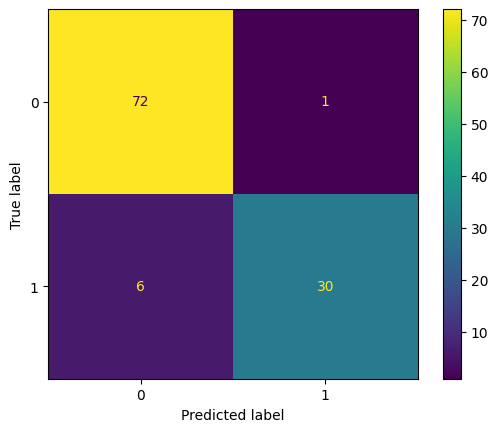

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

plt.show()

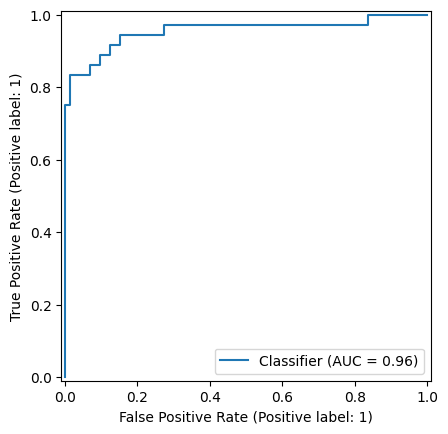

In [56]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    prob
)

plt.show()

In [57]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.get_feature_importance()

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance.head(25))

,Feature,Importance
41,Total Follicles,13.811833
37,Follicle No. (R),10.803326
28,hair growth(Y/N),6.615721
29,Skin darkening (Y/N),5.754712
27,Weight gain(Y/N),5.178285
8,Cycle(R/I),4.047638
22,AMH(ng/mL),3.240756
9,Cycle length(days),2.807662
31,Pimples(Y/N),2.591580
36,Follicle No. (L),2.515300


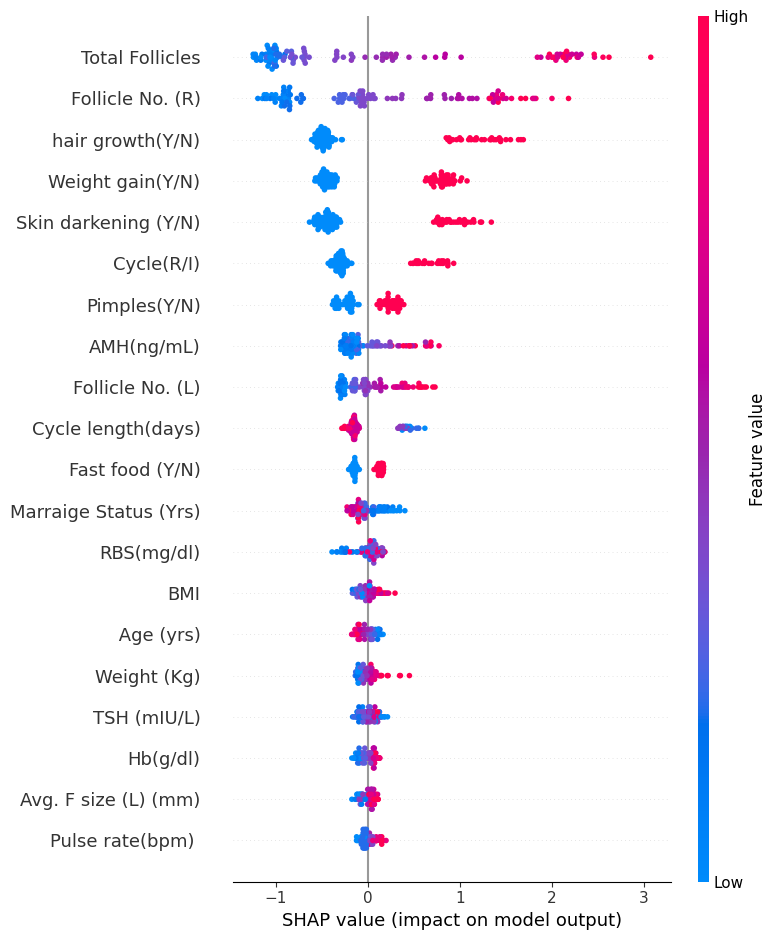

In [58]:
import shap

explainer = shap.TreeExplainer(model)

values = explainer.shap_values(X_test)

shap.summary_plot(
    values,
    X_test
)

In [59]:
model.save_model("clinical_risk_engine.cbm")

In [63]:
import json

schema = {

    "features":list(X.columns)

}

with open(
    "feature_schema.json",
    "w"
) as f:

    json.dump(schema,f,indent=4)

In [64]:
metrics = {

    "Accuracy":float(
        accuracy_score(y_test,pred)
    ),

    "Precision":float(
        precision_score(y_test,pred)
    ),

    "Recall":float(
        recall_score(y_test,pred)
    ),

    "F1":float(
        f1_score(y_test,pred)
    ),

    "ROC_AUC":float(
        roc_auc_score(y_test,prob)
    )
}

with open(
    "metrics.json",
    "w"
) as f:

    json.dump(metrics,f,indent=4)

In [65]:
sample = X.iloc[[0]]

prediction = model.predict(sample)[0]

probability = model.predict_proba(sample)[0][1]

print("Prediction :",prediction)

print("Probability:",probability)

Prediction : 0
Probability: 0.001123816476456858


In [66]:
import os
import json
import zipfile
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import shap

# ==========================================================
# Create Output Directory
# ==========================================================

OUTPUT_DIR = "clinical_risk_engine_output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================================
# Predictions
# ==========================================================

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]

# ==========================================================
# Metrics
# ==========================================================

metrics = {
    "Accuracy": float(accuracy_score(y_test, pred)),
    "Precision": float(precision_score(y_test, pred)),
    "Recall": float(recall_score(y_test, pred)),
    "F1 Score": float(f1_score(y_test, pred)),
    "ROC AUC": float(roc_auc_score(y_test, prob))
}

with open(f"{OUTPUT_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

# ==========================================================
# Classification Report
# ==========================================================

report = classification_report(
    y_test,
    pred,
    output_dict=True
)

pd.DataFrame(report).transpose().to_csv(
    f"{OUTPUT_DIR}/classification_report.csv"
)

# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.to_csv(
    f"{OUTPUT_DIR}/feature_importance.csv",
    index=False
)

# ==========================================================
# Feature Schema
# ==========================================================

with open(f"{OUTPUT_DIR}/feature_schema.json","w") as f:
    json.dump(
        {
            "features": list(X.columns)
        },
        f,
        indent=4
    )

# ==========================================================
# Save Model
# ==========================================================

model.save_model(
    f"{OUTPUT_DIR}/clinical_risk_engine.cbm"
)

# Optional Joblib

joblib.dump(
    model,
    f"{OUTPUT_DIR}/clinical_risk_engine.pkl"
)

# ==========================================================
# Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/confusion_matrix.png",
    dpi=300
)

plt.close()

# ==========================================================
# ROC Curve
# ==========================================================

plt.figure(figsize=(6,6))

RocCurveDisplay.from_predictions(
    y_test,
    prob
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/roc_curve.png",
    dpi=300
)

plt.close()

# ==========================================================
# SHAP Summary Plot
# ==========================================================

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ==========================================================
# Save Sample Predictions
# ==========================================================

sample_predictions = X_test.copy()

sample_predictions["Actual"] = y_test.values
sample_predictions["Prediction"] = pred
sample_predictions["Probability"] = prob

sample_predictions.to_csv(
    f"{OUTPUT_DIR}/sample_predictions.csv",
    index=False
)

# ==========================================================
# Save Cross Validation Scores (if available)
# ==========================================================

if "cv_auc" in globals():

    cv_df = pd.DataFrame({
        "Fold": range(1, len(cv_auc)+1),
        "ROC_AUC": cv_auc
    })

    cv_df.to_csv(
        f"{OUTPUT_DIR}/cross_validation_scores.csv",
        index=False
    )

# ==========================================================
# Zip Everything
# ==========================================================

zip_path = "clinical_risk_engine_output.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:

    for root, dirs, files in os.walk(OUTPUT_DIR):

        for file in files:

            filepath = os.path.join(root, file)

            zipf.write(
                filepath,
                os.path.relpath(filepath, OUTPUT_DIR)
            )

print("="*60)
print("All artifacts saved successfully.")
print(f"Folder : {OUTPUT_DIR}")
print(f"ZIP    : {zip_path}")
print("="*60)

All artifacts saved successfully.
Folder : clinical_risk_engine_output
ZIP    : clinical_risk_engine_output.zip


<Figure size 600x600 with 0 Axes>